# Train-Only Scaling and Leakage Validation

## Objective

This notebook implements feature scaling for the retail demand forecasting
pipeline.

Scaling is performed after the chronological train/validation/test split.

The scaler is fitted using training data only and is then applied to the
training, validation and test data.

## Leakage Prevention Rule

The validation and test sets must not influence the fitted scaling
parameters.

Therefore:

Training data
→ fit scaler

Validation data
→ transform using training scaler

Test data
→ transform using training scaler

The validation and test distributions are not used to calculate the
scaler mean or standard deviation.

## Experimental Protocol

The same fitted scaler will be used for all four deep learning models:

- LSTM
- GRU
- TCN
- Transformer

This ensures that differences between models are not caused by different
scaling procedures.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'google.colab' in sys.modules:
    BASE = Path("/content")
else:
    BASE = Path("..").resolve()

sys.path.insert(0, str(BASE / "src"))

In [2]:
PROCESSED_PATH = BASE / "data" / "m5" / "processed"
RESULTS_PATH = BASE / "results"

RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
sales_clean = pd.read_csv(
    PROCESSED_PATH / "sales_train_validation_clean.csv"
)

print("Sales shape:", sales_clean.shape)

Sales shape: (30490, 1919)


In [4]:
import importlib
import data_splitting

importlib.reload(data_splitting)

from data_splitting import (
    create_chronological_split,
    validate_chronological_split
)

split = create_chronological_split(
    sales_clean,
    train_ratio=0.80,
    validation_ratio=0.10
)

split_validation = validate_chronological_split(split)

for key, val in split_validation.items():
    print(f"{key}: {val}")

train_days: 1530
validation_days: 191
test_days: 192
train_validation_overlap: 0
train_test_overlap: 0
validation_test_overlap: 0
train_before_validation: True
validation_before_test: True
split_valid: True


In [5]:
sales_columns = [
    column
    for column in sales_clean.columns
    if column.startswith("d_")
]

print("Total sales days:", len(sales_columns))
print("Training days:", len(split["train"]))
print("Validation days:", len(split["validation"]))
print("Test days:", len(split["test"]))

Total sales days: 1913
Training days: 1530
Validation days: 191
Test days: 192


In [6]:
train_raw = sales_clean[split["train"]].to_numpy(
    dtype=np.float32
)

validation_raw = sales_clean[split["validation"]].to_numpy(
    dtype=np.float32
)

test_raw = sales_clean[split["test"]].to_numpy(
    dtype=np.float32
)

raw_statistics = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test"
    ],
    "mean": [
        train_raw.mean(),
        validation_raw.mean(),
        test_raw.mean()
    ],
    "std": [
        train_raw.std(),
        validation_raw.std(),
        test_raw.std()
    ],
    "min": [
        train_raw.min(),
        validation_raw.min(),
        test_raw.min()
    ],
    "max": [
        train_raw.max(),
        validation_raw.max(),
        test_raw.max()
    ]
})

display(raw_statistics)

,split,mean,std,min,max
0,train,1.085791,3.936370,0.0,763.0
1,validation,1.277486,3.679600,0.0,349.0
2,test,1.298926,3.528791,0.0,323.0


In [7]:
import scaling

importlib.reload(scaling)

from scaling import (
    fit_scaler_on_training_data,
    transform_sales_splits,
    get_scaler_statistics,
    validate_scaled_data
)

In [8]:
scaler = fit_scaler_on_training_data(
    sales_clean,
    split["train"]
)

In [9]:
scaler_statistics = get_scaler_statistics(scaler)

print("Scaler mean:", scaler_statistics["mean"])
print("Scaler scale:", scaler_statistics["scale"])
print("Scaler variance:", scaler_statistics["variance"])

scaler_statistics_df = pd.DataFrame([scaler_statistics])

scaler_statistics_df.to_csv(
    RESULTS_PATH / "scaler_statistics.csv",
    index=False
)

display(scaler_statistics_df)

Scaler mean: 1.085791248389593
Scaler scale: 3.9363701492578524
Scaler variance: 15.495009951968287


,mean,scale,variance
0,1.085791,3.93637,15.49501


In [10]:
scaled_data = transform_sales_splits(
    sales_clean,
    split,
    scaler
)

print("Scaled train shape:",
      scaled_data["train"].shape)

print("Scaled validation shape:",
      scaled_data["validation"].shape)

print("Scaled test shape:",
      scaled_data["test"].shape)

Scaled train shape: (30490, 1530)
Scaled validation shape: (30490, 191)
Scaled test shape: (30490, 192)


In [11]:
validation_results = validate_scaled_data(
    scaled_data,
    scaler,
    train_raw
)

for key, val in validation_results.items():
    print(f"{key}: {val}")

train_scaled_mean: -1.2057955522948305e-08
train_scaled_std: 0.9999999403953552
validation_scaled_mean: 0.048698365688323975
validation_scaled_std: 0.9347698092460632
test_scaled_mean: 0.05414504557847977
test_scaled_std: 0.8964580297470093
scaler_mean: 1.085791248389593
scaler_scale: 3.9363701492578524
training_mean_before_scaling: 1.0857912302017212
training_std_before_scaling: 3.9363698959350586
training_centered: True
training_standardized: True
scaler_fitted_on_training_only: True
scaling_valid: True


In [12]:
scaling_validation_df = pd.DataFrame(
    [validation_results]
)

scaling_validation_df.to_csv(
    RESULTS_PATH / "scaling_validation.csv",
    index=False
)

assert validation_results["scaling_valid"] is True

print("Scaling validation passed.")

Scaling validation passed.


In [13]:
from sklearn.preprocessing import StandardScaler

full_data = sales_clean[sales_columns].to_numpy(
    dtype=np.float32
)

full_scaler = StandardScaler()

full_scaler.fit(
    full_data.reshape(-1, 1)
)

print("Training-only scaler mean:",
      scaler.mean_[0])

print("Full-data scaler mean:",
      full_scaler.mean_[0])

print()

print("Training-only scaler scale:",
      scaler.scale_[0])

print("Full-data scaler scale:",
      full_scaler.scale_[0])

Training-only scaler mean: 1.085791248389593
Full-data scaler mean: 1.126322153733316

Training-only scaler scale: 3.9363701492578524
Full-data scaler scale: 3.8731084132705003


## Why Full-Data Scaling Is Not Used

Fitting a scaler on the complete dataset would allow information from the
validation and test periods to influence the transformation applied to the
training data.

Although the scaler does not directly use the target label in a supervised
classification sense, its mean and standard deviation are still calculated
from observations that occur in the future relative to the training period.

This creates temporal information leakage.

Therefore, the experimental pipeline fits the scaler exclusively on the
training period and reuses that scaler for validation and test data.

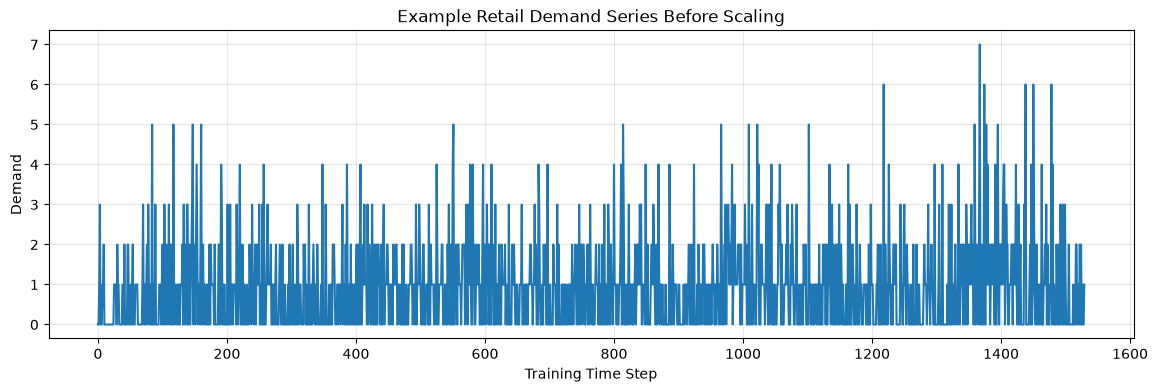

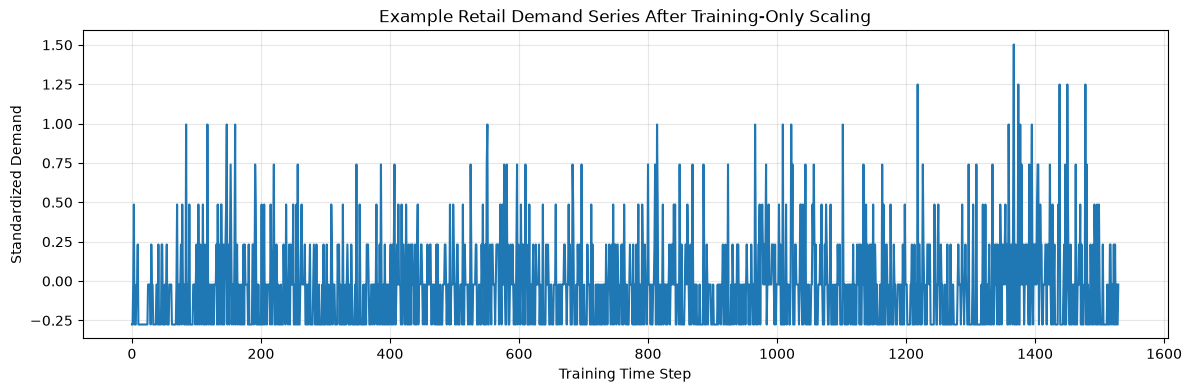

In [14]:
sample_series = 100

raw_sample = train_raw[sample_series]
scaled_sample = scaled_data["train"][sample_series]

plt.figure(figsize=(14, 4))
plt.plot(raw_sample)
plt.xlabel("Training Time Step")
plt.ylabel("Demand")
plt.title("Example Retail Demand Series Before Scaling")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(scaled_sample)
plt.xlabel("Training Time Step")
plt.ylabel("Standardized Demand")
plt.title("Example Retail Demand Series After Training-Only Scaling")
plt.grid(alpha=0.3)
plt.show()

In [15]:
for split_name, data in scaled_data.items():
    print(
        split_name,
        "NaN:",
        np.isnan(data).sum(),
        "Infinity:",
        np.isinf(data).sum()
    )

assert all(
    np.isnan(data).sum() == 0
    for data in scaled_data.values()
)

assert all(
    np.isinf(data).sum() == 0
    for data in scaled_data.values()
)

print("No NaN or infinite values introduced during scaling.")

train NaN: 0 Infinity: 0
validation NaN: 0 Infinity: 0
test NaN: 0 Infinity: 0
No NaN or infinite values introduced during scaling.


In [16]:
assert scaled_data["train"].shape[1] == 1530
assert scaled_data["validation"].shape[1] == 191
assert scaled_data["test"].shape[1] == 192

print("All scaled split dimensions are correct.")

All scaled split dimensions are correct.


In [17]:
final_checks = {
    "total_days": len(sales_columns),
    "train_days": len(split["train"]),
    "validation_days": len(split["validation"]),
    "test_days": len(split["test"]),
    "split_valid": split_validation["split_valid"],
    "scaling_valid": validation_results["scaling_valid"],
    "train_nan": int(np.isnan(scaled_data["train"]).sum()),
    "validation_nan": int(np.isnan(scaled_data["validation"]).sum()),
    "test_nan": int(np.isnan(scaled_data["test"]).sum()),
    "train_inf": int(np.isinf(scaled_data["train"]).sum()),
    "validation_inf": int(np.isinf(scaled_data["validation"]).sum()),
    "test_inf": int(np.isinf(scaled_data["test"]).sum())
}

display(final_checks)

assert final_checks["split_valid"] is True
assert final_checks["scaling_valid"] is True
assert final_checks["train_nan"] == 0
assert final_checks["validation_nan"] == 0
assert final_checks["test_nan"] == 0
assert final_checks["train_inf"] == 0
assert final_checks["validation_inf"] == 0
assert final_checks["test_inf"] == 0

print("======================================")
print("VALIDATION PASSED")
print("======================================")

{'total_days': 1913,
 'train_days': 1530,
 'validation_days': 191,
 'test_days': 192,
 'split_valid': True,
 'scaling_valid': True,
 'train_nan': 0,
 'validation_nan': 0,
 'test_nan': 0,
 'train_inf': 0,
 'validation_inf': 0,
 'test_inf': 0}

VALIDATION PASSED


# Conclusion

The M5 demand data was scaled using a leakage-safe procedure.

The chronological split established in contains:

- 1,530 training days
- 191 validation days
- 192 test days

A StandardScaler was fitted exclusively on the training data.

The fitted training scaler was then applied to the validation and test
periods without recalculating scaling parameters.

The training data has approximately zero mean and unit standard deviation
after scaling, while validation and test distributions retain their own
natural distributional characteristics after transformation.

No NaN or infinite values were introduced.

This scaling procedure will be shared by all four deep learning models:

1. LSTM
2. GRU
3. TCN
4. Transformer

The test set remains untouched for model development and will only be used
during final evaluation.